# **Machine Learning Workflow**

## **1. Dataset Information**

### Titanic Dataset Overview

Dataset **Titanic** merupakan dataset klasik yang sering digunakan dalam pembelajaran **data science, machine learning, dan analisis data**. Dataset ini berisi informasi mengenai penumpang kapal Titanic dan apakah mereka selamat atau tidak saat tragedi tenggelamnya kapal Titanic pada tahun 1912.

Tujuan umum analisis dataset ini adalah untuk **memprediksi apakah seorang penumpang selamat (Survived) atau tidak** berdasarkan karakteristik yang dimiliki oleh penumpang tersebut seperti kelas tiket, usia, jenis kelamin, jumlah keluarga di kapal, dan lain-lain.



---

### Dataset Variables

Berikut adalah penjelasan setiap variabel yang terdapat pada dataset Titanic.

| Variabel | Tipe Data | Deskripsi |
|--------|--------|--------|
| PassengerId | Integer | ID unik untuk setiap penumpang |
| Survived | Integer (0/1) | Status keselamatan penumpang (0 = Tidak selamat, 1 = Selamat) |
| Pclass | Integer | Kelas tiket penumpang (1 = Kelas pertama, 2 = Kelas kedua, 3 = Kelas ketiga) |
| Name | String | Nama lengkap penumpang |
| Sex | String | Jenis kelamin penumpang |
| Age | Float | Usia penumpang dalam tahun |
| SibSp | Integer | Jumlah saudara kandung atau pasangan yang ikut di kapal |
| Parch | Integer | Jumlah orang tua atau anak yang ikut di kapal |
| Ticket | String | Nomor tiket penumpang |
| Fare | Float | Harga tiket yang dibayar penumpang |
| Cabin | String | Nomor kabin tempat penumpang menginap |
| Embarked | String | Pelabuhan tempat penumpang naik ke kapal |

---

### Embarked Variable Explanation

Variabel **Embarked** menunjukkan pelabuhan tempat penumpang naik ke kapal Titanic.

| Kode | Pelabuhan |
|-----|-----|
| C | Cherbourg |
| S | Southampton |
| Q | Queenstown |

---

### Target Variable

Dalam banyak analisis machine learning pada dataset ini, variabel **Survived** digunakan sebagai **target variable** untuk membangun model klasifikasi.

- **0 → Tidak selamat**
- **1 → Selamat**

---

### Summary

Dataset Titanic berisi informasi demografis dan sosial dari penumpang kapal Titanic yang dapat digunakan untuk menganalisis faktor-faktor yang mempengaruhi peluang keselamatan penumpang.

## **2. Data Understanding**

In [82]:
#!pip install pandas numpy matplotlib seaborn luwiji

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

from luwiji.knn import illustration, demo

In [84]:
df = pd.read_csv("titanic (1).csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [85]:
print("Statistics of the data:\n")
print(df.describe())

print("\n\nInformation of the data:\n")
print(df.info())

Statistics of the data:

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


Information of the data:

<class 'pandas.DataFrame'>
R

In [86]:
print("Data types of the data:\n")
print(df.dtypes)

Data types of the data:

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


## **2. Quick EDA**

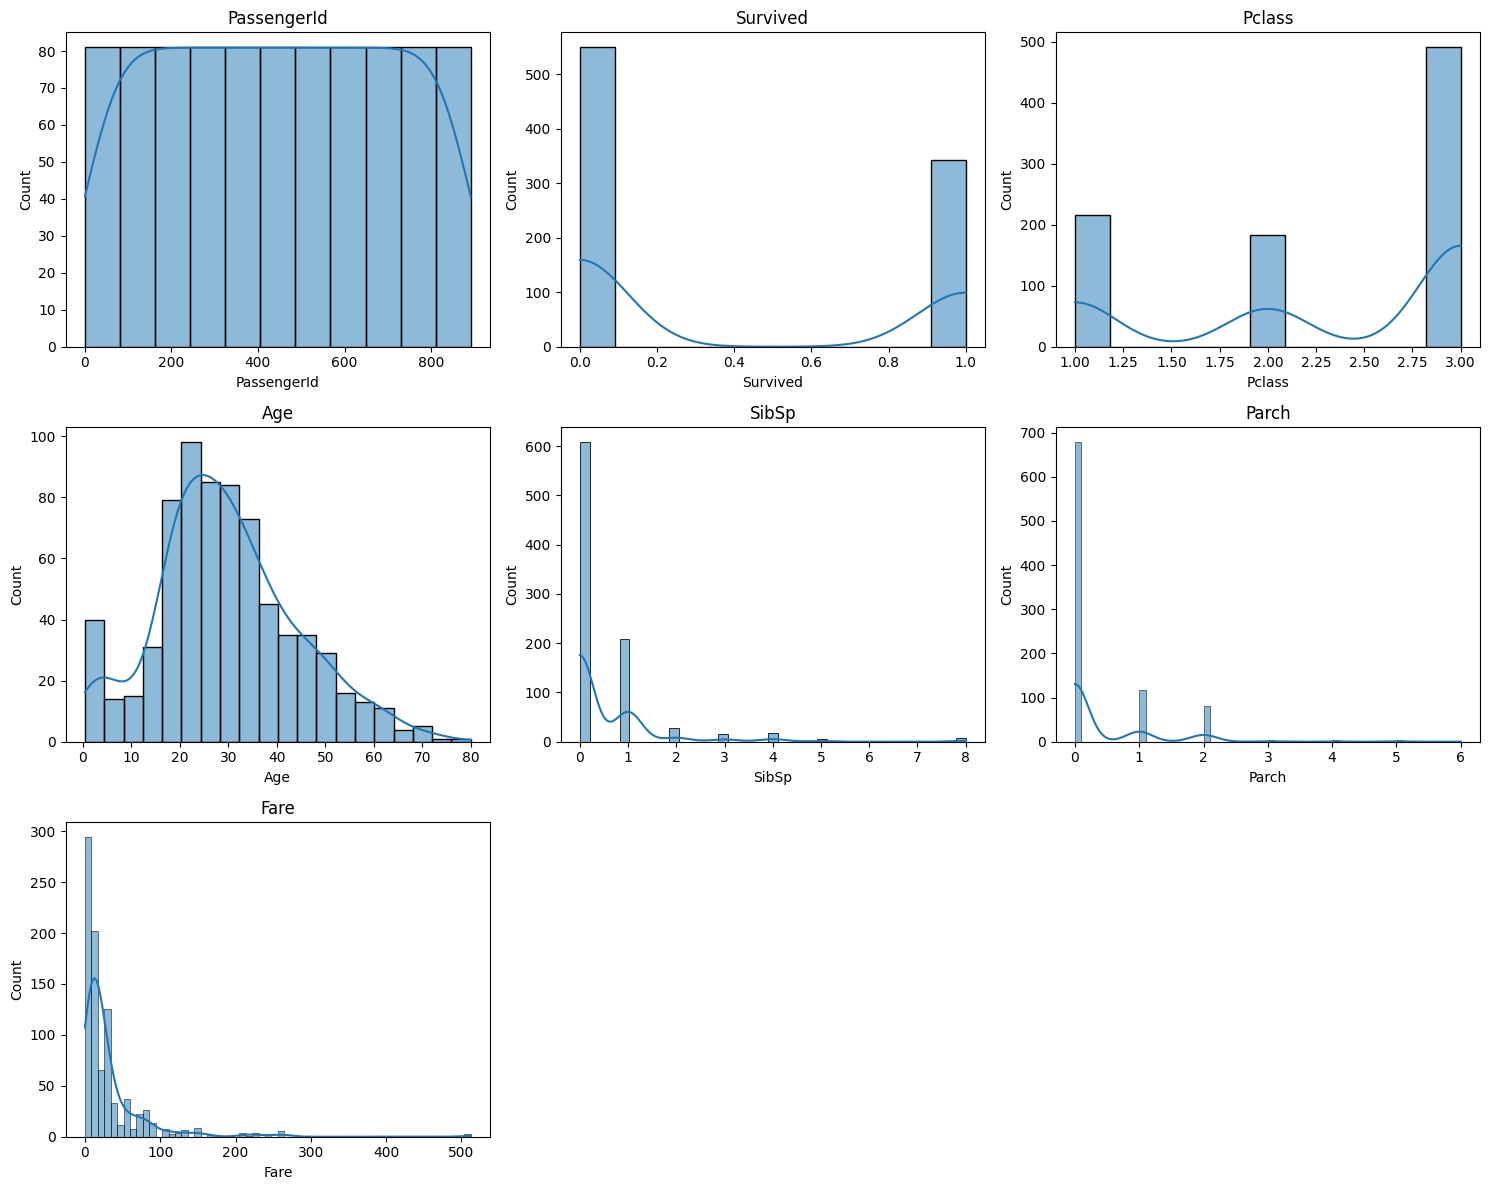

In [87]:
# Histogram Variable Numeric

# memilih kolom numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3  # jumlah plot per baris
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 4*n_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

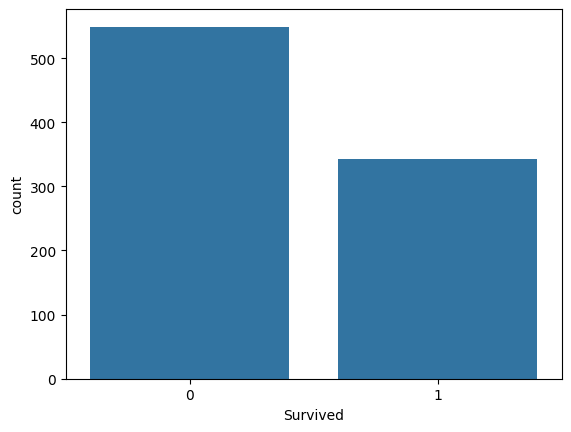

In [88]:
# Gender & Survived barplot

sns.countplot(x='Survived', data=df)
plt.show()

## **3. Data Cleaning**
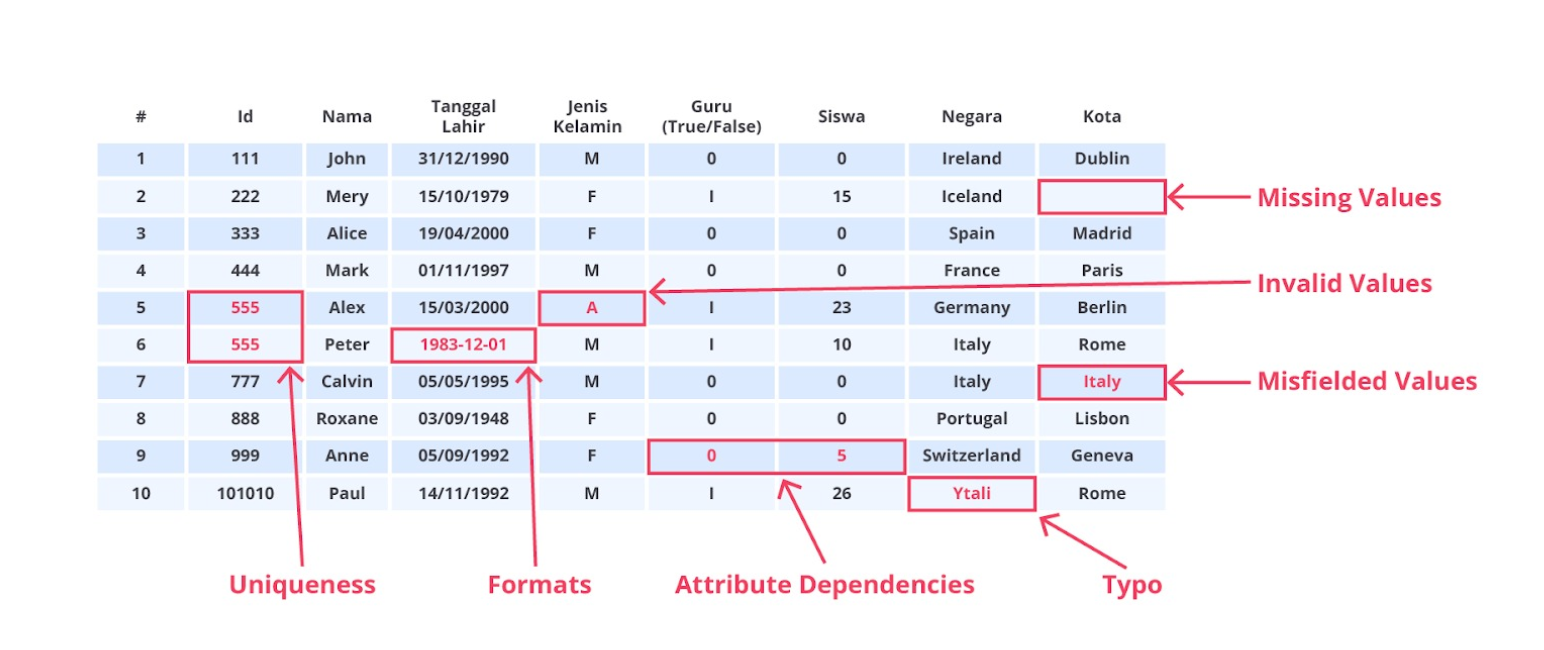

### **3.1 Irrelevant Variable**

Drop Variabel `Name` dan `Ticket` 

Pada dataset Titanic, variabel **`Name`** dan **`Ticket`** biasanya tidak digunakan secara langsung dalam proses pemodelan machine learning karena beberapa alasan berikut.

 1. Variabel `Name`  
Variabel `Name` berisi nama lengkap setiap penumpang. Variabel ini umumnya tidak digunakan karena:

- Tidak memiliki hubungan langsung dengan kemungkinan penumpang selamat atau tidak.
- Hampir setiap penumpang memiliki **nama yang unik**, sehingga jumlah kategorinya sangat banyak (**high cardinality**).
- Sulit diubah menjadi fitur numerik yang bermakna untuk model.

Namun, variabel ini masih dapat dimanfaatkan melalui **feature engineering**, misalnya dengan mengekstrak **title** dari nama seperti *Mr*, *Mrs*, *Miss*, atau *Master* yang dapat memberikan informasi tambahan tentang penumpang.

---

 2. Variabel `Ticket`
Variabel `Ticket` berisi nomor tiket penumpang. Variabel ini biasanya tidak digunakan karena:

- Nomor tiket hanya berfungsi sebagai **identifier**, bukan informasi yang memiliki makna numerik.
- Format tiket tidak konsisten (kombinasi huruf, angka, dan simbol).
- Banyak nilai tiket yang unik sehingga memiliki **cardinality tinggi** dan kurang informatif bagi model.

---

In [89]:
df.drop(columns=['PassengerId', "Name", "Ticket"], inplace=True)
df.shape

(891, 9)

### **3.2 Drop Duplicates**

In [90]:
print("Jumlah data duplikat: ", df.duplicated().sum())

Jumlah data duplikat:  107


### **3.3 Missing Values**

In [91]:
print("Jumlah data missing: \n", df.isnull().sum())

Jumlah data missing: 
 Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


In [92]:
# menghitung jumlah missing value
missing_count = df.isnull().sum()

# menghitung persentase missing value
missing_percentage = (df.isnull().sum() / len(df)) * 100

# membuat tabel hasil
missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percentage
})

# mengurutkan dari yang terbesar
missing_table = missing_table.sort_values(by='Missing Percentage (%)', ascending=False)

print(missing_table)

          Missing Count  Missing Percentage (%)
Cabin               687               77.104377
Age                 177               19.865320
Embarked              2                0.224467
Survived              0                0.000000
Pclass                0                0.000000
SibSp                 0                0.000000
Sex                   0                0.000000
Fare                  0                0.000000
Parch                 0                0.000000


<Axes: >

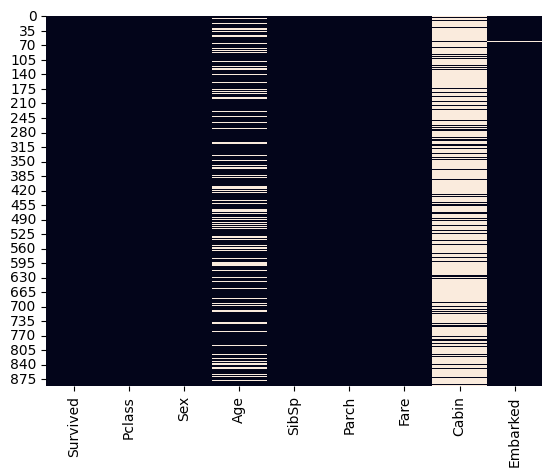

In [93]:
sns.heatmap(df.isnull(), cbar=False)

In [94]:
# Menghapus kolom Cabin
df = df.drop(columns=['Cabin'])

# Mengisi missing value pada Age & Embarked dengan median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Mengecek kembali missing value
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### **3.4 Check Irrelevant Values**

In [95]:
# Menampilkan unique value dan jumlahnya per kolom
for col in df.columns:
    unique_vals = df[col].unique()
    num_unique = df[col].nunique()
    
    print(f"Kolom '{col}' memiliki {num_unique} unique value(s):")
    print(unique_vals)
    print('-' * 50)

Kolom 'Survived' memiliki 2 unique value(s):
[0 1]
--------------------------------------------------
Kolom 'Pclass' memiliki 3 unique value(s):
[3 1 2]
--------------------------------------------------
Kolom 'Sex' memiliki 2 unique value(s):
<StringArray>
['male', 'female']
Length: 2, dtype: str
--------------------------------------------------
Kolom 'Age' memiliki 88 unique value(s):
[22.   38.   26.   35.   28.   54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.    8.   19.   40.   66.   42.   21.   18.
  3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.   16.
 25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.   14.5
 70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.   56.
 50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.   60.
 10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.    0.67
 30.5   0.42 34.5  74.  ]
--------------------------------------------------
Kolom 'SibSp' memiliki 7 unique 

## **4. Data Splitting**

### Data Splitting dalam Machine Learning

### Apa itu Data Splitting?

**Data splitting** adalah proses membagi dataset menjadi beberapa bagian sebelum membangun model machine learning.  
Tujuan utama dari data splitting adalah agar model dapat dievaluasi secara objektif terhadap data yang belum pernah dilihat sebelumnya (unseen data).

Umumnya dataset dibagi menjadi:

- **Training Set** → digunakan untuk melatih model
- **Validation Set** → digunakan untuk tuning hyperparameter (opsional)
- **Testing Set** → digunakan untuk evaluasi akhir model

---

### Tujuan Data Splitting

1. **Menghindari Overfitting**  
   Agar model tidak hanya menghafal data training.

2. **Mengukur Generalisasi Model**  
   Untuk mengetahui seberapa baik model bekerja pada data baru.

3. **Evaluasi yang Objektif**  
   Memberikan gambaran performa model yang lebih realistis.

4. **Mendukung Hyperparameter Tuning**  
   Validation set membantu memilih model terbaik.

---

### Metode Data Splitting

Berikut adalah beberapa metode data splitting yang umum digunakan dalam machine learning.

| Metode | Deskripsi | Kelebihan | Kekurangan |
|--------|------------|------------|------------|
| Holdout Method | Dataset dibagi sekali menjadi training dan testing (misal 80:20 atau 70:30). | - Sederhana dan cepat<br>- Mudah diterapkan<br>- Cocok untuk dataset besar | - Hasil evaluasi bisa bergantung pada pembagian data<br>- Kurang stabil untuk dataset kecil |
| K-Fold Cross Validation | Dataset dibagi menjadi K bagian (fold). Model dilatih dan diuji sebanyak K kali dengan fold yang berbeda sebagai data test. | - Evaluasi lebih stabil<br>- Menggunakan seluruh data sebagai training dan testing secara bergantian<br>- Cocok untuk dataset kecil | - Lebih lambat secara komputasi<br>- Tidak cocok untuk data time series |
| Stratified Splitting | Mirip K-Fold atau holdout, tetapi proporsi kelas target dijaga tetap seimbang di setiap split. | - Cocok untuk dataset imbalanced<br>- Distribusi kelas tetap konsisten<br>- Evaluasi lebih adil | - Tidak selalu diperlukan untuk dataset seimbang<br>- Sedikit lebih kompleks |
| Time Series Splitting | Data dibagi berdasarkan urutan waktu. Data masa lalu digunakan untuk memprediksi masa depan. | - Menghindari data leakage pada time series<br>- Realistis untuk data berbasis waktu | - Tidak bisa diacak (shuffle)<br>- Hanya cocok untuk data berurutan waktu |

---

### Ilustrasi Singkat

### 1. Holdout
```
Training (80%) | Testing (20%)
```

### 2. K-Fold (contoh K=5)
```
Fold1 → Test | Sisanya → Train
Fold2 → Test | Sisanya → Train
...
Fold5 → Test | Sisanya → Train
```

### 3. Stratified
Distribusi target tetap sama di setiap split.

Contoh:
- Data asli → 70% kelas 0, 30% kelas 1
- Setelah split → tetap 70% : 30%

### 4. Time Series
```
Train: 2018-2020 → Test: 2021
Train: 2018-2021 → Test: 2022
```

---

### Kesimpulan

Pemilihan metode data splitting bergantung pada:

- Ukuran dataset
- Distribusi kelas
- Jenis data (tabular atau time series)
- Kebutuhan evaluasi model

Untuk dataset klasifikasi biasa seperti Titanic:
- Gunakan **Train-Test Split**
- Gunakan **Stratified Split** jika data tidak seimbang

Untuk dataset time series:
- Gunakan **Time Series Split**

### **4.1 Splitting Dengan Train Test Split**

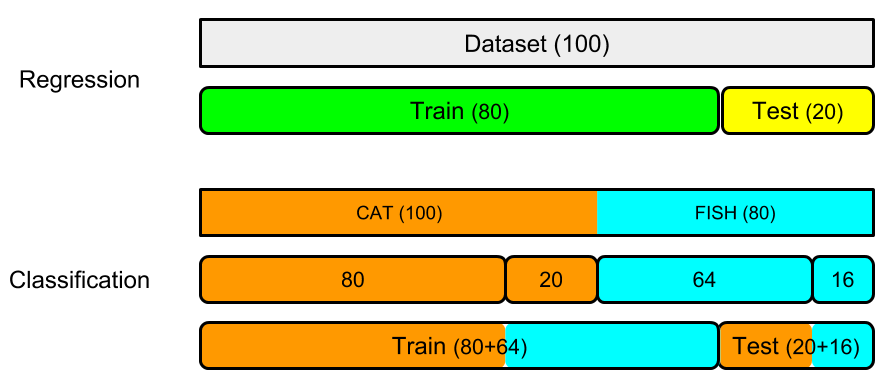

In [96]:
illustration.train_test_split

In [97]:
from sklearn.model_selection import train_test_split

# Misalnya X = fitur dan y = target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Membagi data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Jumlah data training:", X_train.shape)
print("Jumlah data testing:", X_test.shape)

Jumlah data training: (712, 7)
Jumlah data testing: (179, 7)


### **4.1 Splitting Dengan K-Fold Cross Validation**

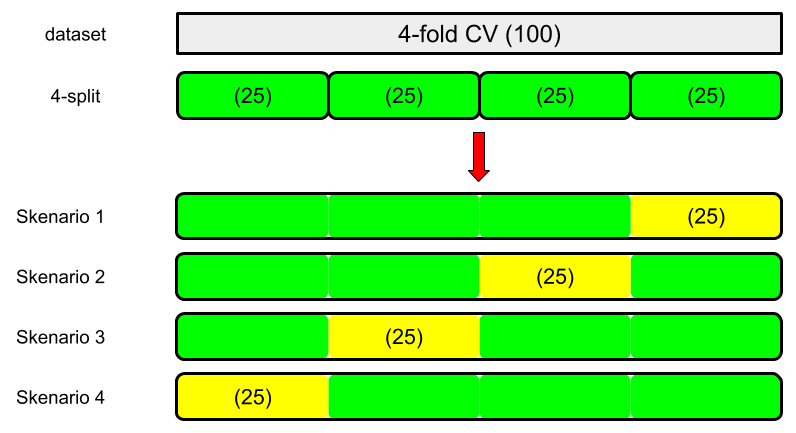

In [98]:
illustration.kfold_cv

In [99]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, test_index in kf.split(X):
    
    X_train_kf = X.iloc[train_index]
    X_test_kf = X.iloc[test_index]
    
    y_train_kf = y.iloc[train_index]
    y_test_kf = y.iloc[test_index]
    
    print("Train size:", X_train_kf.shape)
    print("Test size:", X_test_kf.shape)
    print("-----------")

Train size: (712, 7)
Test size: (179, 7)
-----------
Train size: (713, 7)
Test size: (178, 7)
-----------
Train size: (713, 7)
Test size: (178, 7)
-----------
Train size: (713, 7)
Test size: (178, 7)
-----------
Train size: (713, 7)
Test size: (178, 7)
-----------


## **5. Feature Transformation**

### **5.1 Scaling**

In [100]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [101]:
scaler = StandardScaler()

numerical_features = ['Age', 'Fare']

# fit pada training data
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# transform test data
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# cek hasil
print(X_train[numerical_features].head())
print(X_test[numerical_features].head())

          Age      Fare
692 -0.112078  0.513812
481 -0.112078 -0.662563
527 -0.112078  3.955399
855 -0.879807 -0.467874
801  0.118241 -0.115977


          Age      Fare
565 -0.419170 -0.159704
160  1.116290 -0.327324
553 -0.572716 -0.512122
860  0.885971 -0.368795
241 -0.112078 -0.339817


### **5.2 Encoding**

In [102]:
categorical_features = ['Pclass', 'Sex', 'Embarked', 'SibSp', 'Parch']

# encoding
X_train = pd.get_dummies(X_train, columns=categorical_features)
X_test = pd.get_dummies(X_test, columns=categorical_features)

# menyamakan kolom train dan test
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# cek hasil
print(X_train.head())
print(X_test.head())

          Age      Fare  Pclass_1  Pclass_2  Pclass_3  Sex_female  Sex_male  \
692 -0.112078  0.513812     False     False      True       False      True   
481 -0.112078 -0.662563     False      True     False       False      True   
527 -0.112078  3.955399      True     False     False       False      True   
855 -0.879807 -0.467874     False     False      True        True     False   
801  0.118241 -0.115977     False      True     False        True     False   

     Embarked_C  Embarked_Q  Embarked_S  ...  SibSp_4  SibSp_5  SibSp_8  \
692       False       False        True  ...    False    False    False   
481       False       False        True  ...    False    False    False   
527       False       False        True  ...    False    False    False   
855       False       False        True  ...    False    False    False   
801       False       False        True  ...    False    False    False   

     Parch_0  Parch_1  Parch_2  Parch_3  Parch_4  Parch_5  Parch_6  
692  

In [103]:
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (712, 24)
Shape X_test: (179, 24)


## **6. Modelling**

In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

### **6.1 Logistic Regression**

In [105]:
logreg = LogisticRegression()

# training model
logreg.fit(X_train, y_train)

# prediksi
y_pred_logreg = logreg.predict(X_test)

# evaluasi
print("Accuracy Logistic Regression:", accuracy_score(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

Accuracy Logistic Regression: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### **6.2 K-Nearest Neighbour**

In [106]:
knn = KNeighborsClassifier(n_neighbors=5)

# training model
knn.fit(X_train, y_train)

# prediksi
y_pred_knn = knn.predict(X_test)

# evaluasi
print("Accuracy KNN:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy KNN: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



### **6.3 Comparasion**

In [ ]:
# !pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]



In [109]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logreg),
        accuracy_score(y_test, y_pred_knn)
    ]
})

comparison.style.background_gradient(subset=['Accuracy'], cmap='Blues')

,Model,Accuracy
0,Logistic Regression,0.804469
1,KNN,0.810056


## **7. Save Model (Model Persistence)**

**Penyimpanan model (model persistence)** adalah proses menyimpan model machine learning yang telah dilatih agar dapat digunakan kembali di masa depan tanpa perlu melakukan proses training ulang.

Setelah model selesai dilatih dan memiliki performa yang baik, model tersebut biasanya disimpan ke dalam sebuah file. File ini kemudian dapat digunakan untuk:

- Melakukan prediksi pada data baru
- Mengintegrasikan model ke dalam aplikasi
- Deployment ke sistem produksi
- Reproducibility eksperimen

Dengan menyimpan model, proses komputasi menjadi lebih efisien karena kita tidak perlu melatih model dari awal setiap kali ingin menggunakannya.

---

#### Format Penyimpanan Model

Berikut beberapa format yang umum digunakan untuk menyimpan model machine learning di Python.

| Format | Deskripsi | Kelebihan | Kekurangan |
|------|------|------|------|
| Pickle (.pkl) | Format serialisasi objek Python menggunakan library `pickle`. Model disimpan sebagai objek Python. | Mudah digunakan, standar Python, cocok untuk berbagai model scikit-learn | Kurang aman jika file berasal dari sumber tidak terpercaya |
| Joblib (.joblib) | Format penyimpanan yang dioptimalkan untuk objek Python berukuran besar seperti model machine learning. | Lebih efisien untuk model besar, lebih cepat untuk loading model | Masih spesifik untuk ekosistem Python |
| ONNX (.onnx) | Format model yang bersifat interoperable sehingga model dapat digunakan di berbagai framework dan bahasa pemrograman. | Dapat digunakan lintas platform dan framework | Proses konversi model bisa lebih kompleks |
| HDF5 (.h5) | Format yang sering digunakan untuk menyimpan model deep learning, khususnya pada TensorFlow dan Keras. | Efisien untuk model deep learning dan mendukung struktur kompleks | Kurang umum untuk model klasik seperti scikit-learn |

---

#### Kesimpulan

Pemilihan format penyimpanan model bergantung pada kebutuhan penggunaan model tersebut.

- **Pickle / Joblib** → paling umum untuk model scikit-learn  
- **ONNX** → digunakan jika model perlu dijalankan di berbagai platform  
- **HDF5** → banyak digunakan pada model deep learning

In [111]:
import pickle

# Simpan model
pickle.dump(logreg, open("logreg_model_titanic_v1.pkl", "wb"))

In [112]:
# Contoh cara load model
model = pickle.load(open("logreg_model_titanic_v1.pkl", "rb"))

## **Tambahan Mengenai Data Leakage**

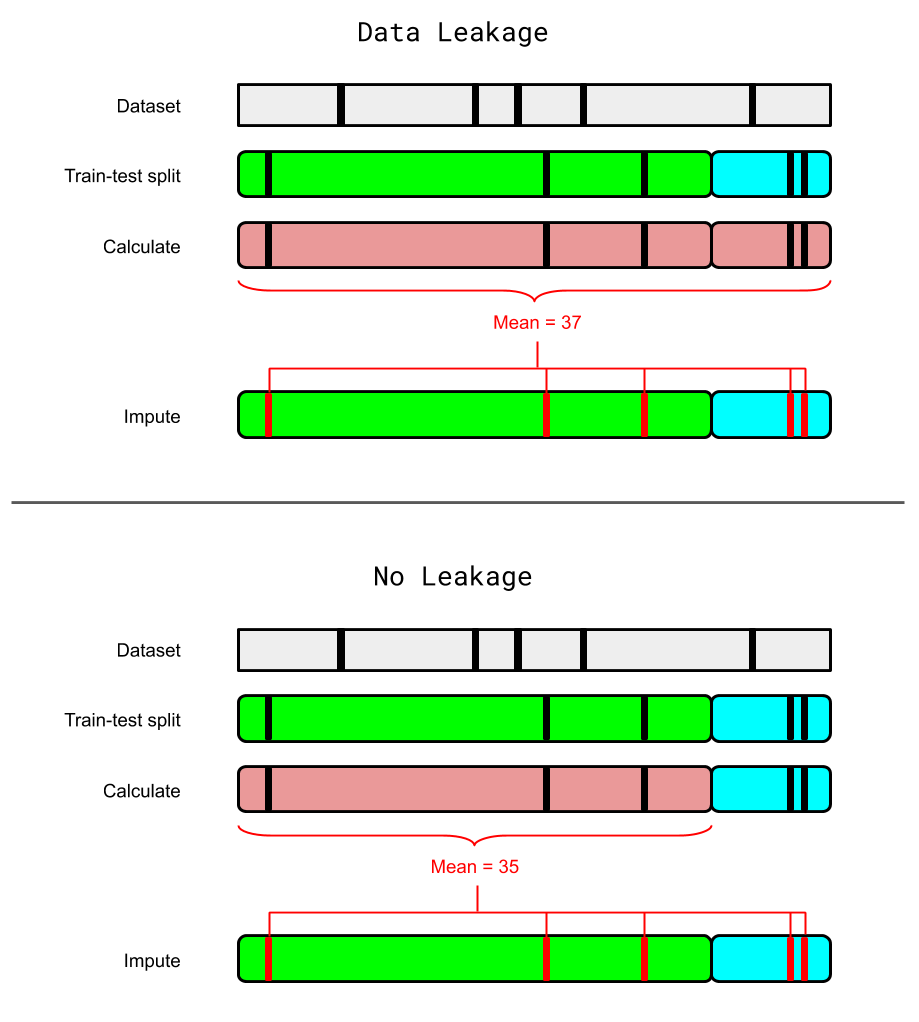

In [113]:
illustration.data_leakage

**Data leakage** adalah kondisi ketika informasi dari **data yang seharusnya tidak tersedia saat proses prediksi** secara tidak sengaja digunakan saat proses training model. Hal ini menyebabkan model memperoleh informasi tambahan yang tidak realistis sehingga performa model terlihat sangat baik pada saat evaluasi, tetapi gagal ketika digunakan pada data baru di dunia nyata.

Dengan kata lain, model **“bocor informasi”** dari data test atau dari masa depan ke dalam proses training.

---

### Dampak Data Leakage

Data leakage dapat menyebabkan beberapa masalah serius dalam proses pengembangan model machine learning, antara lain:

- **Performa model terlihat terlalu tinggi (overly optimistic)**  
  Model tampak sangat akurat saat evaluasi, tetapi performanya menurun drastis saat digunakan pada data baru.

- **Model tidak dapat melakukan generalisasi dengan baik**  
  Karena model telah “melihat” informasi yang seharusnya tidak tersedia.

- **Evaluasi model menjadi tidak valid**  
  Hasil pengujian tidak lagi mencerminkan kemampuan model yang sebenarnya.

---

### Contoh Data Leakage

#### 1. Melakukan Preprocessing Sebelum Data Splitting

Misalnya melakukan standardisasi pada seluruh dataset sebelum membaginya menjadi training dan testing.

```python
scaler.fit_transform(X)   # SALAH
train_test_split(...)
```

Hal ini menyebabkan informasi dari data test ikut digunakan saat menghitung mean dan standar deviasi.

**Cara yang benar:**

```python
train_test_split(...)
scaler.fit(X_train)
scaler.transform(X_test)
```

---

#### 2. Menggunakan Variabel yang Mengandung Informasi Masa Depan

Contoh pada dataset medis:

| Fitur | Target |
|------|------|
| Hasil operasi | Pasien meninggal atau tidak |

Jika tujuan model adalah memprediksi kemungkinan pasien meninggal **sebelum operasi**, maka fitur **hasil operasi** tidak boleh digunakan karena informasi tersebut berasal dari masa depan.

---

### 3. Menggunakan Data Test Saat Training

Misalnya melakukan tuning parameter menggunakan seluruh dataset termasuk data test.

Data test seharusnya hanya digunakan **untuk evaluasi akhir model**.

---

## Cara Menghindari Data Leakage

Beberapa cara yang dapat dilakukan untuk mencegah data leakage antara lain:

1. **Lakukan data splitting terlebih dahulu** sebelum preprocessing.
2. **Fit preprocessing hanya pada data training**, lalu gunakan transform pada data testing.
3. **Hindari penggunaan fitur yang mengandung informasi masa depan**.
4. Gunakan **pipeline machine learning** agar alur preprocessing dan training lebih terkontrol.
5. Pisahkan dengan jelas antara **training data, validation data, dan testing data**.

---

## Kesimpulan

Data leakage adalah salah satu masalah paling umum dalam machine learning yang dapat menyebabkan **evaluasi model menjadi tidak akurat**. Oleh karena itu, penting untuk memastikan bahwa proses preprocessing, training, dan evaluasi dilakukan dengan benar sehingga model yang dihasilkan dapat bekerja dengan baik pada data baru.